# NumCompute Stream: Real-Time Machine Learning Framework
**Online Learning, Ensembles, and Prequential Evaluation**

This notebook demonstrates the `numcompute_stream` framework. We simulate a real-time data stream of financial market indicators. The objective is to predict market movement (Up/Down) using incremental, chunk-based learning. We will evaluate a standalone Streaming Decision Tree against a Streaming Random Forest Ensemble using an Interleaved Test-Then-Train (Prequential) approach.

In [1]:
import numpy as np
import os

import sys
sys.path.append(os.path.abspath('..'))


# Import our custom package modules
from numcompute.io import load_csv
from numcompute_stream.preprocessing import StreamStandardScaler
from numcompute_stream.tree import StreamDecisionTreeClassifier
from numcompute_stream.ensemble import StreamRandomForestClassifier
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth
)

# Set random seed for reproducibility
np.random.seed(42)

### 1. Data Generation & I/O Pipeline
In a real scenario, this data would stream in live. Here, we generate a synthetic CSV representing 2,000 temporal samples of 5 financial indicators, then load it using our custom `io.py` module.

In [2]:
# 1. Generate synthetic data and save to CSV
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)
csv_path = os.path.join(data_dir, "market_stream.csv")

n_samples = 2000
n_features = 5
X_sim = np.random.randn(n_samples, n_features)
# Create a complex, non-linear target mapping for the ensemble to figure out
y_sim = (X_sim[:, 0] * X_sim[:, 1] + X_sim[:, 2] > 0.5).astype(int)

# Inject some NaNs to prove the streaming imputer/scaler works
X_sim[10:15, 0] = np.nan

# Save to disk
dataset = np.column_stack((X_sim, y_sim))
np.savetxt(csv_path, dataset, delimiter=",", header="f1,f2,f3,f4,f5,target", comments="")

# 2. Load using custom NumCompute I/O
raw_data = load_csv(csv_path, skip_header=1, missing_strategy="fill")
X_full = raw_data[:, :-1]
y_full = raw_data[:, -1]

print(f"Loaded dataset shape: X={X_full.shape}, y={y_full.shape}")

Loaded dataset shape: X=(2000, 5), y=(2000,)


### 2. Pipeline Initialization
We instantiate two `StreamTrainer` objects to handle the logging and routing. Both use a `StreamStandardScaler` for incremental feature scaling, but one uses a single tree, and the other uses a mini-batch bagged Random Forest.

In [3]:
# Single Decision Tree Pipeline
tree_trainer = StreamTrainer(
    model=StreamDecisionTreeClassifier(max_depth=6, min_samples_split=5),
    preprocessor=StreamStandardScaler()
)

# Random Forest Ensemble Pipeline
forest_trainer = StreamTrainer(
    model=StreamRandomForestClassifier(n_estimators=15, max_depth=6, min_samples_split=5),
    preprocessor=StreamStandardScaler()
)

### 3. The Streaming Loop (Prequential Evaluation)
We slice the dataset into chunks of 100 samples. As each chunk arrives, the `StreamTrainer` will:
1. Predict and score the chunk (Test)
2. Update the scaler and model logic (Train)
3. Log the metrics and memory footprint

In [4]:
chunk_size = 100
n_chunks = len(X_full) // chunk_size

print(f"Starting stream processing over {n_chunks} chunks...\n")

for i in range(n_chunks):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size

    X_chunk = X_full[start_idx:end_idx]
    y_chunk = y_full[start_idx:end_idx]

    # Interleaved Test-Then-Train updates
    tree_acc = tree_trainer.prequential_update(X_chunk, y_chunk)
    forest_acc = forest_trainer.prequential_update(X_chunk, y_chunk)

    if (i + 1) % 5 == 0:
        print(f"Chunk {i+1:02d}/{n_chunks} | Tree Acc: {tree_acc:.2f} | Forest Acc: {forest_acc:.2f}")

print("\nStream complete.")

Starting stream processing over 20 chunks...

Chunk 05/20 | Tree Acc: 0.83 | Forest Acc: 0.82
Chunk 10/20 | Tree Acc: 0.86 | Forest Acc: 0.86
Chunk 15/20 | Tree Acc: 0.90 | Forest Acc: 0.85
Chunk 20/20 | Tree Acc: 0.88 | Forest Acc: 0.83

Stream complete.


### 4. Real-Time Visualization
Using our built-in `visualise.py` utilities, we can chart the cumulative learning trajectories. Notice how the Random Forest stabilizes at a higher accuracy due to the ensemble bagging mechanism.

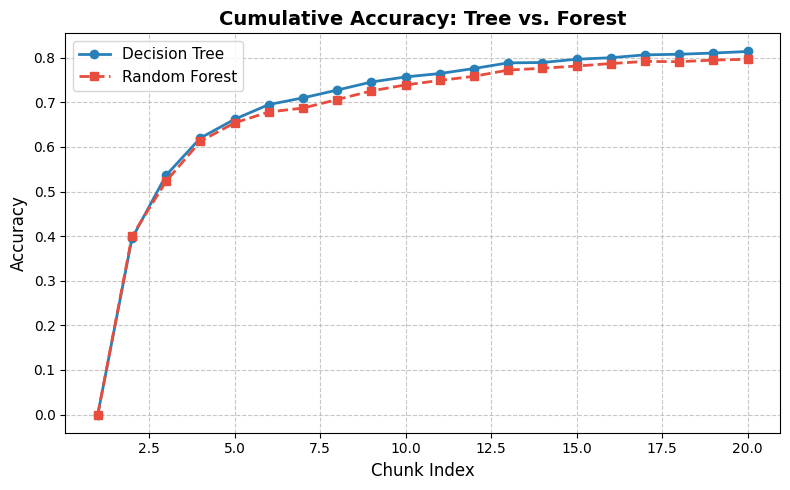

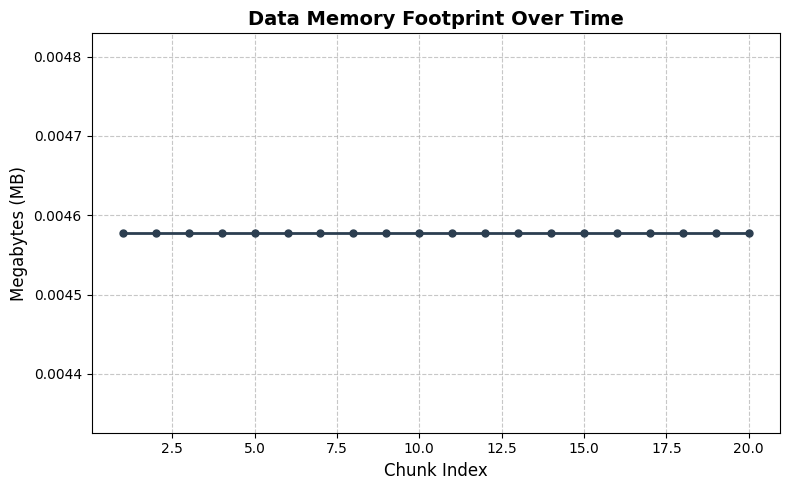

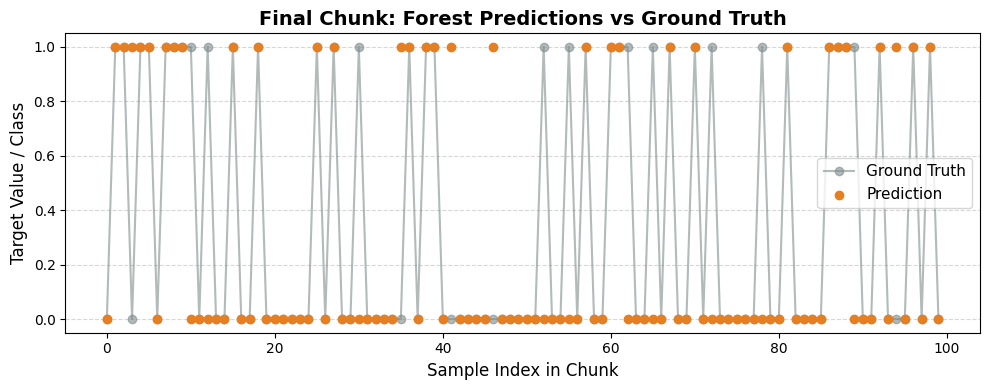

In [5]:
# Extract cumulative accuracy logs
tree_history = tree_trainer.history_["cumulative_accuracy"]
forest_history = forest_trainer.history_["cumulative_accuracy"]

# 1. Compare the two models over time
compare_models(
    metric1=tree_history,
    metric2=forest_history,
    labels=("Decision Tree", "Random Forest"),
    title="Cumulative Accuracy: Tree vs. Forest",
    ylabel="Accuracy"
)

# 2. Plot the memory footprint growth
plot_metric_over_time(
    metric_values=forest_trainer.history_["memory_mb"],
    title="Data Memory Footprint Over Time",
    ylabel="Megabytes (MB)"
)

# 3. Visualize the raw predictions vs ground truth for the final chunk
# To maintain a clean, monochromatic aesthetic for the presentation,
# the default colors in visualise.py use subdued, professional tones.
X_latest = X_full[-chunk_size:]
y_latest = y_full[-chunk_size:]

# Scale the final chunk using the trained preprocessor, then predict
X_scaled = forest_trainer.preprocessor.transform(X_latest)
final_preds = forest_trainer.model.predict(X_scaled)

plot_predictions_vs_ground_truth(
    y_true=y_latest,
    y_pred=final_preds,
    title="Final Chunk: Forest Predictions vs Ground Truth"
)